In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
path = r"H:\Escola\Python\Etapa-3\Atividade_2\Tabela 1.1.1.xls"
indicador_1 = pd.read_excel(path, engine="xlrd")

bruto = pd.read_excel(path, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1


In [ ]:
media_nacional = indicador_1.loc[indicador_1["uf_regiao"] == "Brasil", "total"].item()
media_nacional


In [ ]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

acima_media = estados.loc[
    estados["total"] > media_nacional,
    ["uf_regiao", "total"],
].sort_values("total", ascending=False)

print(f"Média nacional (Brasil): {media_nacional:.2f} horas/semana")
print(f"Estados acima da média: {len(acima_media)}")
acima_media


In [ ]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

abaixo_media = estados.loc[
    estados["total"] < media_nacional,
    ["uf_regiao", "total"],
].sort_values("total", ascending=False)

print(f"Média nacional (Brasil): {media_nacional:.2f} horas/semana")
print(f"Estados abaixo da média: {len(abaixo_media)}")
abaixo_media


In [ ]:
brasil = indicador_1.loc[indicador_1["uf_regiao"] == "Brasil"].iloc[0]

homem = (brasil["homem_branca"] + brasil["homem_preta_parda"]) / 2
mulher = (brasil["mulher_branca"] + brasil["mulher_preta_parda"]) / 2

percentual = (mulher - homem) / homem * 100

print(f"Homens (média das cores):   {homem:.2f} h/semana")
print(f"Mulheres (média das cores): {mulher:.2f} h/semana")
print(f"Mulheres trabalham {percentual:.1f}% a mais que homens em casa, no Brasil.")

perc_branca = (brasil["mulher_branca"] / brasil["homem_branca"] - 1) * 100
perc_preta_parda = (brasil["mulher_preta_parda"] / brasil["homem_preta_parda"] - 1) * 100
print(f"Branca:        mulheres +{perc_branca:.1f}%")
print(f"Preta ou parda: mulheres +{perc_preta_parda:.1f}%")


In [ ]:
minas = indicador_1.loc[indicador_1["uf_regiao"] == "Minas Gerais"].iloc[0]
horas_p1 = minas["mulher_preta_parda"] - minas["mulher_branca"]
print(f"Mulheres preta parda trabalham: {horas_p1:.2f} h/semana a mais que mulheres brancas")

brasil = indicador_1.loc[indicador_1["uf_regiao"] == "Brasil"].iloc[0]
horas_p2 = brasil["mulher_preta_parda"] - brasil["homem_branca"]
print(f"Mulheres preta parda trabalham: {horas_p2:.2f} h/semana a mais que homens brancos")

amapa = indicador_1.loc[indicador_1["uf_regiao"] == "Amapá"].iloc[0]
horas_p3 = amapa["mulher_preta_parda"] - amapa["mulher_branca"]
print(f"Mulheres preta parda trabalham: {horas_p3:.2f} h/semana a mais que mulheres brancas no Amapá")


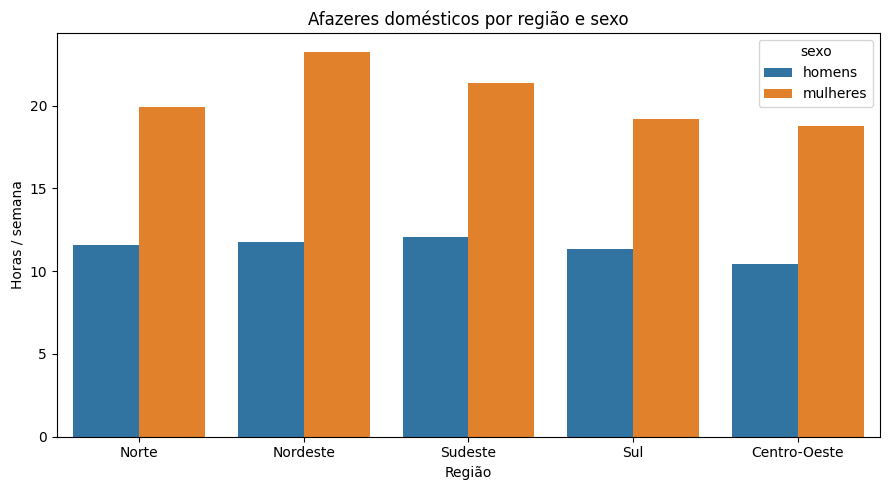

In [ ]:
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()


In [ ]:
path = r"H:\Escola\Python\Etapa-3\Atividade_3\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"
formacao = pd.read_excel(path, header=2)

formacao_total = formacao[
    ["Unnamed: 0", "Homens", "Mulheres"]
].rename(
    columns={
        "Unnamed: 0": "uf_regiao",
        "Homens": "total_homens",
        "Mulheres": "total_mulheres",
    }
)

formacao_stem = formacao[
    ["Unnamed: 0", "Homens.1", "Mulheres.1"]
].rename(
    columns={
        "Unnamed: 0": "uf_regiao",
        "Homens.1": "homens",
        "Mulheres.1": "mulheres",
    }
)

formacao_saude = formacao[
    ["Unnamed: 0", "Homens.2", "Mulheres.2"]
].rename(
    columns={
        "Unnamed: 0": "uf_regiao",
        "Homens.2": "homens",
        "Mulheres.2": "mulheres",
    }
)

formacao


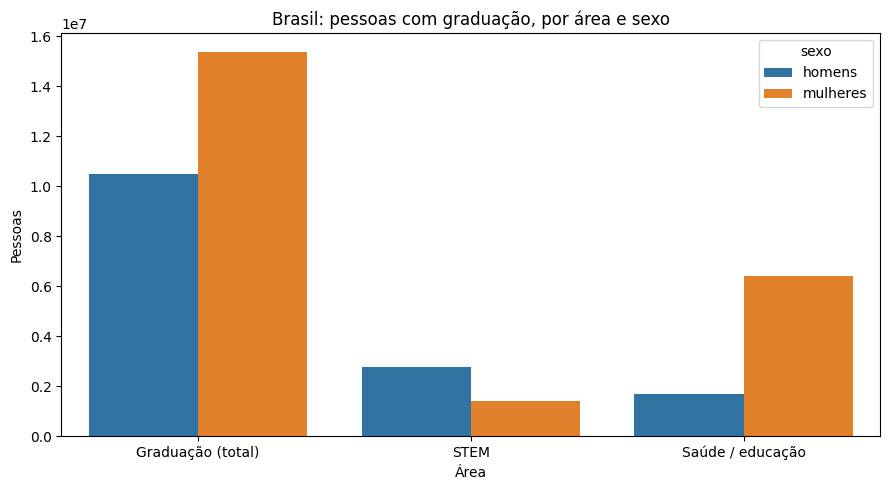

In [ ]:
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),
        ],
    }
)

brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()


In [ ]:
path = r"H:\Escola\Python\Etapa-3\Atividade_4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

indicador_1 = pd.read_excel(path, header=2)

tabela_1 = indicador_1.iloc[0:5570, 1:]

tabela_1


In [ ]:
tabela_1.columns


In [ ]:
tabela_1["diferença"] = tabela_1["População Município 2010\n(Sinopse)"] - tabela_1["População Censo 2022"]

tabela_1.to_csv(r"H:\Escola\Python\Etapa-3\Atividade_4\diferença20222010.csv", sep=";")

tabela_result = (
    tabela_1.groupby("UF")[[
        "População Município 2010\n(Sinopse)",
        "População Censo 2022",
        "diferença"
    ]]
    .sum()
    .reset_index()
)

tabela_1.to_csv(r"H:\Escola\Python\Etapa-3\Atividade_4\diferença20222010estado.csv", sep=";")

tabela_result


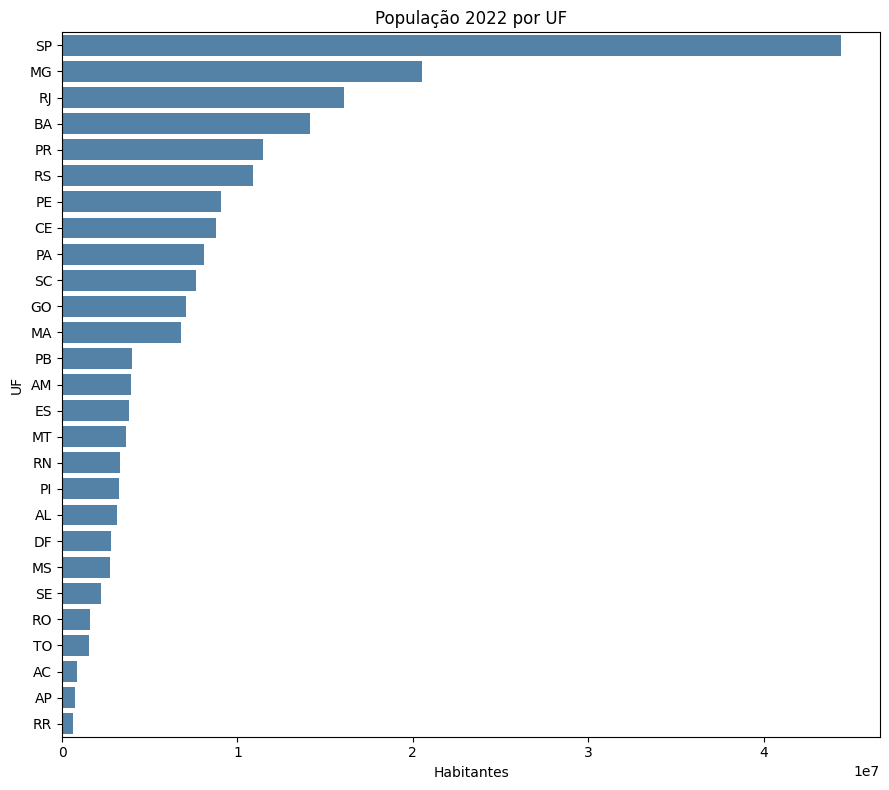

In [ ]:
pop_estado = tabela_result[["UF", "População Censo 2022"]].rename(
    columns={"População Censo 2022": "2022"}
)

ordem = pop_estado.sort_values("2022", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=ordem, y="UF", x="2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()
